# Лабораторная работа №6
  
## Тема: Кластеризация (DBSCAN, OPTICS)
  
## Цель работы: Ознакомиться с методами кластеризации модуля Sklearn.

**Студент:** Магомедов Имран Борисович  
**Группа:** ПИЖ-Б-О-22-1  
**Курс/Семестр:** 4/8  

## Методика и порядок выполнения работы

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
import warnings
warnings.filterwarnings('ignore')

### Загрузка данных

2. Загрузка данных

In [15]:
data = pd.read_csv('/content/drive/MyDrive/NCFU/ОиАБД/Отчеты/Лабораторная работа №6/data/CC GENERAL.csv').iloc[:, 1:].dropna()
print("Исходные данные:")
print(data.head())
print(f"\nРазмер данных после удаления пропусков: {data.shape}")
print(f"Признаки: {list(data.columns)}")

Исходные данные:
       BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0    40.900749           0.818182      95.40              0.00   
1  3202.467416           0.909091       0.00              0.00   
2  2495.148862           1.000000     773.17            773.17   
4   817.714335           1.000000      16.00             16.00   
5  1809.828751           1.000000    1333.28              0.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                   95.40      0.000000             0.166667   
1                    0.00   6442.945483             0.000000   
2                    0.00      0.000000             1.000000   
4                    0.00      0.000000             0.083333   
5                 1333.28      0.000000             0.666667   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000                          0.000000   


### DBSCAN

1. K-means для сравнения

In [16]:
no_labeled_data = data.values
k_means = KMeans(init='k-means++', n_clusters=3, n_init=15, random_state=42)
k_means.fit(no_labeled_data)
print("K-means выполнена для сравнения")

K-means выполнена для сравнения


2. Стандартизация данных

In [17]:
data_array = np.array(data, dtype='float')
min_max_scaler = preprocessing.StandardScaler()
scaled_data = min_max_scaler.fit_transform(data_array)
print(f"Данные стандартизированы: {scaled_data.shape}")

Данные стандартизированы: (8636, 17)


3. DBSCAN с параметрами по умолчанию

In [18]:
clustering = DBSCAN().fit(scaled_data)
labels_default = clustering.labels_
n_clusters_default = len(set(labels_default)) - (1 if -1 in labels_default else 0)
n_noise_default = list(labels_default).count(-1)
noise_percent_default = n_noise_default / len(labels_default) * 100

In [19]:
print(f"Метки кластеров: {set(labels_default)}")
print(f"Количество кластеров: {n_clusters_default}")
print(f"Количество шумовых точек: {n_noise_default}")
print(f"Процент шума: {noise_percent_default:.2f}%")

Метки кластеров: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(-1)}
Количество кластеров: 36
Количество шумовых точек: 6488
Процент шума: 75.13%


Параметры DBSCAN:
- eps: максимальное расстояние между двумя точками для их принадлежности к одному кластеру
- min_samples: минимальное количество точек в окрестности для формирования ядра кластера
- metric: метрика расстояния (euclidean, manhattan и др.)
- algorithm: алгоритм поиска соседей (auto, ball_tree, kd_tree, brute)
- leaf_size: размер листа для деревьев
- p: параметр для метрики Минковского

4. Зависимость от eps

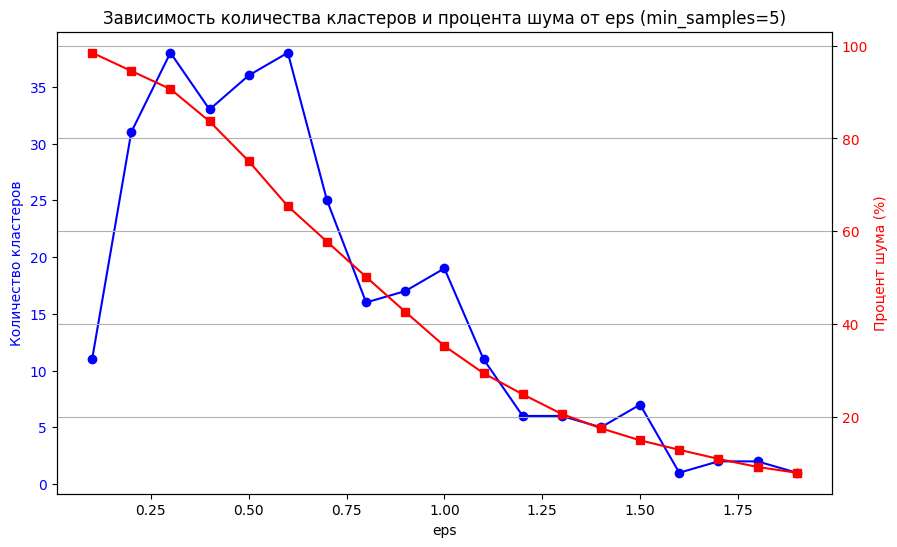

In [20]:
eps_range = np.arange(0.1, 2.0, 0.1)
n_clusters_list = []
noise_percent_list = []

for eps in eps_range:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(scaled_data)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_percent = n_noise / len(labels) * 100
    n_clusters_list.append(n_clusters)
    noise_percent_list.append(noise_percent)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('eps')
ax1.set_ylabel('Количество кластеров', color='b')
ax1.plot(eps_range, n_clusters_list, 'b-o', label='Количество кластеров')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.set_ylabel('Процент шума (%)', color='r')
ax2.plot(eps_range, noise_percent_list, 'r-s', label='Процент шума')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Зависимость количества кластеров и процента шума от eps (min_samples=5)')
plt.grid()
plt.show()

5. Зависимость от min_samples

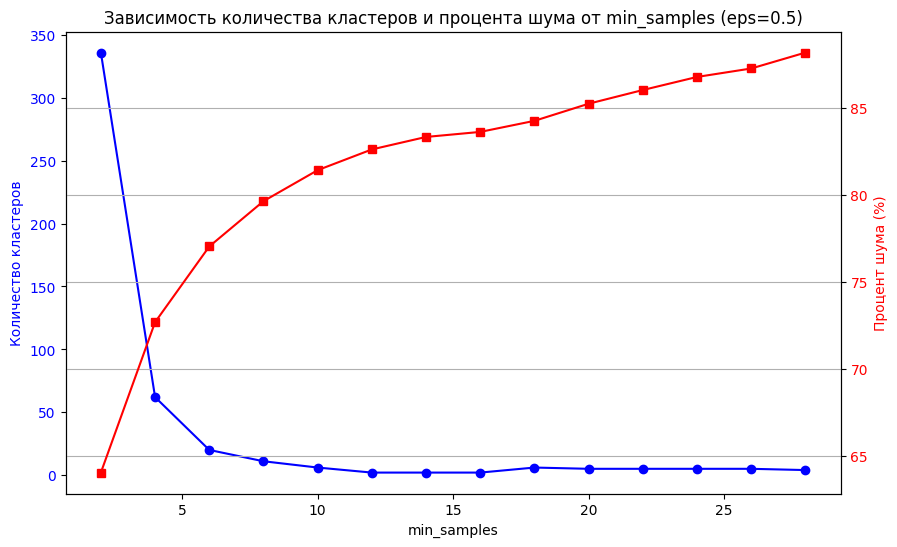

In [21]:
min_samples_range = range(2, 30, 2)
n_clusters_list = []
noise_percent_list = []

for min_samples in min_samples_range:
    dbscan = DBSCAN(eps=0.5, min_samples=min_samples)
    labels = dbscan.fit_predict(scaled_data)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_percent = n_noise / len(labels) * 100
    n_clusters_list.append(n_clusters)
    noise_percent_list.append(noise_percent)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('min_samples')
ax1.set_ylabel('Количество кластеров', color='b')
ax1.plot(min_samples_range, n_clusters_list, 'b-o', label='Количество кластеров')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.set_ylabel('Процент шума (%)', color='r')
ax2.plot(min_samples_range, noise_percent_list, 'r-s', label='Процент шума')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Зависимость количества кластеров и процента шума от min_samples (eps=0.5)')
plt.grid()
plt.show()

6. Поиск оптимальных параметров (5-7 кластеров, шум < 12%)

In [23]:
# Расширяем диапазоны параметров
eps_range = np.arange(0.1, 3.0, 0.2)
min_samples_range = range(2, 25, 2)

optimal_params = []

for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(scaled_data)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_percent = n_noise / len(labels) * 100

        if 5 <= n_clusters <= 7 and noise_percent <= 12:
            optimal_params.append((eps, min_samples, n_clusters, noise_percent))
            print(f"Найдено: eps={eps:.1f}, min_samples={min_samples}, кластеров={n_clusters}, шум={noise_percent:.2f}%")

if optimal_params:
    print(f"\nНайдено {len(optimal_params)} комбинаций параметров:")
    for params in optimal_params:
        print(f"  eps={params[0]:.1f}, min_samples={params[1]}, кластеров={params[2]}, шум={params[3]:.2f}%")

    # Выбор параметров с наименьшим шумом
    best_params = min(optimal_params, key=lambda x: x[3])
    best_eps, best_min_samples = best_params[0], best_params[1]
    print(f"\nВыбраны оптимальные параметры: eps={best_eps:.1f}, min_samples={best_min_samples}")
    print(f"  кластеров={best_params[2]}, шум={best_params[3]:.2f}%")
else:
    print("\nНе найдено параметров с 5-7 кластерами и шумом ≤ 12%")
    print("Попробуем найти параметры с 3-8 кластерами и шумом ≤ 15%")

    # Расширенные условия
    for eps in np.arange(0.1, 3.5, 0.2):
        for min_samples in range(2, 30, 2):
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(scaled_data)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            noise_percent = n_noise / len(labels) * 100

            if 3 <= n_clusters <= 8 and noise_percent <= 15:
                optimal_params.append((eps, min_samples, n_clusters, noise_percent))

    if optimal_params:
        print(f"\nНайдено {len(optimal_params)} комбинаций:")
        for params in optimal_params[:10]:  # Показываем первые 10
            print(f"  eps={params[0]:.1f}, min_samples={params[1]}, кластеров={params[2]}, шум={params[3]:.2f}%")

        best_params = min(optimal_params, key=lambda x: (abs(x[2] - 5), x[3]))
        best_eps, best_min_samples = best_params[0], best_params[1]
        print(f"\nВыбраны параметры: eps={best_eps:.1f}, min_samples={best_min_samples}")
        print(f"  кластеров={best_params[2]}, шум={best_params[3]:.2f}%")
    else:
        print("Используем параметры по умолчанию")
        best_eps, best_min_samples = 0.5, 5
        print(f"eps={best_eps}, min_samples={best_min_samples}")

Найдено: eps=1.7, min_samples=4, кластеров=5, шум=10.25%

Найдено 1 комбинаций параметров:
  eps=1.7, min_samples=4, кластеров=5, шум=10.25%

Выбраны оптимальные параметры: eps=1.7, min_samples=4
  кластеров=5, шум=10.25%


7. Визуализация результатов с PCA

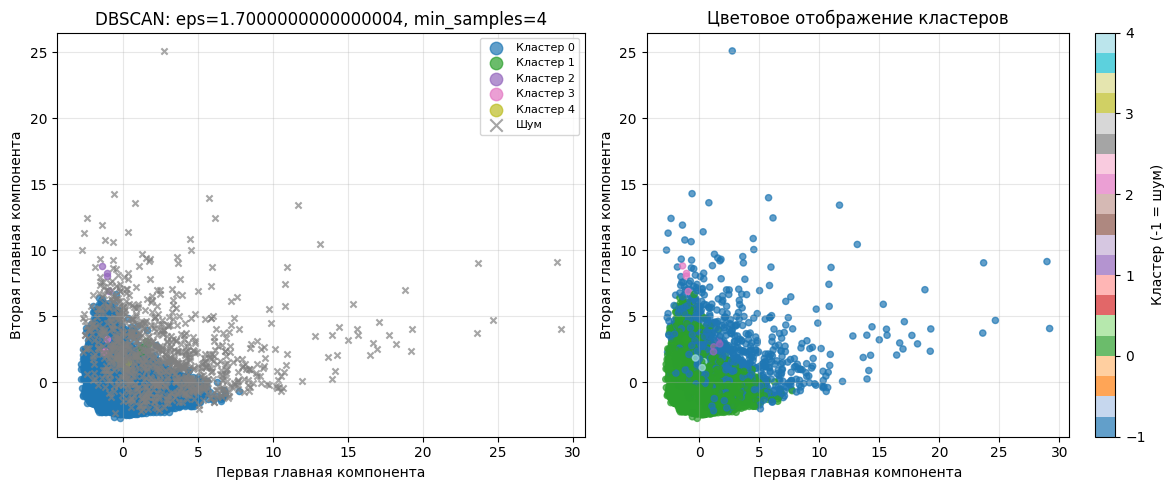

In [24]:
dbscan_optimal = DBSCAN(eps=best_eps, min_samples=best_min_samples)
optimal_labels = dbscan_optimal.fit_predict(scaled_data)

# Понижение размерности до 2 с помощью PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(scaled_data)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
unique_labels = set(optimal_labels)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
for label, color in zip(unique_labels, colors):
    if label == -1:
        color = 'gray'
        marker = 'x'
        label_name = 'Шум'
    else:
        marker = 'o'
        label_name = f'Кластер {label}'
    mask = optimal_labels == label
    plt.scatter(data_pca[mask, 0], data_pca[mask, 1], c=[color],
               marker=marker, s=20, label=label_name, alpha=0.7)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title(f'DBSCAN: eps={best_eps}, min_samples={best_min_samples}')
plt.legend(markerscale=2, fontsize=8)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=optimal_labels, cmap='tab20', s=20, alpha=0.7)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Цветовое отображение кластеров')
plt.colorbar(label='Кластер (-1 = шум)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### OPTICS

1. Параметры OPTICS

Параметры OPTICS:
- min_samples: минимальное количество точек в окрестности для формирования ядра
- max_eps: максимальное расстояние для поиска соседей (аналог eps в DBSCAN)
- metric: метрика расстояния
- cluster_method: метод кластеризации ('xi', 'dbscan')
- xi: параметр для метода 'xi' (порог для извлечения кластеров)
- predecessor_correction: коррекция предшественников

Атрибуты OPTICS:
- reachability_: массив достижимости для каждой точки
- ordering_: порядок обработки точек
- core_distances_: расстояния до ядра для каждой точки

2. Подбор параметров OPTICS для получения результатов близких к DBSCAN

In [25]:
optics_optimal = OPTICS(min_samples=best_min_samples, max_eps=best_eps,
                        cluster_method='dbscan')
optics_labels = optics_optimal.fit_predict(scaled_data)

n_clusters_optics = len(set(optics_labels)) - (1 if -1 in optics_labels else 0)
n_noise_optics = list(optics_labels).count(-1)
noise_percent_optics = n_noise_optics / len(optics_labels) * 100

print(f"OPTICS с min_samples={best_min_samples}, max_eps={best_eps}")
print(f"Количество кластеров: {n_clusters_optics}")
print(f"Процент шума: {noise_percent_optics:.2f}%")

OPTICS с min_samples=4, max_eps=1.7000000000000004
Количество кластеров: 5
Процент шума: 10.28%


DBSCAN:
- Требует задания eps (фиксированный радиус)
- Не чувствителен к вариациям плотности
- Проще в интерпретации

OPTICS:
- Не требует задания eps (можно задать max_eps как верхнюю границу)
- Может находить кластеры разной плотности
- Строит график достижимости для анализа иерархии кластеров
- Более гибкий, но сложнее в настройке

3. Визуализация результатов OPTICS и график достижимости

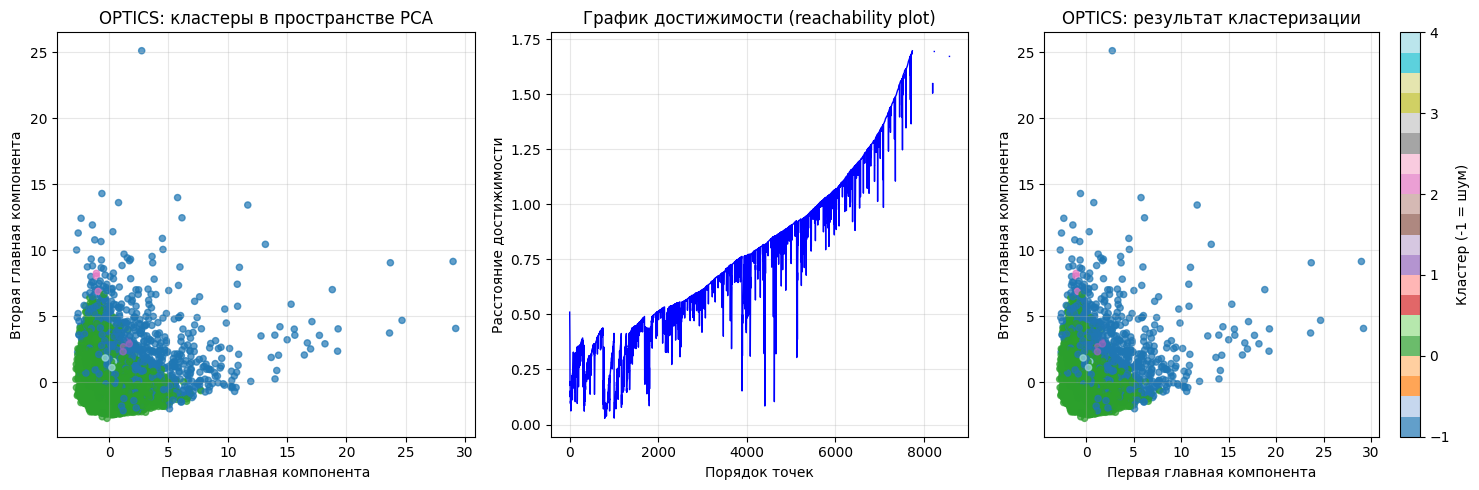

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Визуализация кластеров в пространстве PCA
axes[0].scatter(data_pca[:, 0], data_pca[:, 1], c=optics_labels, cmap='tab20', s=20, alpha=0.7)
axes[0].set_xlabel('Первая главная компонента')
axes[0].set_ylabel('Вторая главная компонента')
axes[0].set_title('OPTICS: кластеры в пространстве PCA')
axes[0].grid(True, alpha=0.3)

# График достижимости (reachability plot)
ordering = optics_optimal.ordering_
reachability = optics_optimal.reachability_[ordering]

axes[1].plot(range(len(reachability)), reachability, 'b-', linewidth=1)
axes[1].set_xlabel('Порядок точек')
axes[1].set_ylabel('Расстояние достижимости')
axes[1].set_title('График достижимости (reachability plot)')
axes[1].grid(True, alpha=0.3)

# График с цветовой кодировкой
axes[2].scatter(data_pca[:, 0], data_pca[:, 1], c=optics_labels, cmap='tab20', s=20, alpha=0.7)
axes[2].set_xlabel('Первая главная компонента')
axes[2].set_ylabel('Вторая главная компонента')
axes[2].set_title('OPTICS: результат кластеризации')
colorbar = axes[2].colorbar = plt.colorbar(axes[2].collections[0], ax=axes[2])
colorbar.set_label('Кластер (-1 = шум)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

4. Исследование различных метрик

metric=euclidean: кластеров=5, шум=10.28%
metric=manhattan: кластеров=25, шум=49.86%
metric=chebyshev: кластеров=4, шум=2.19%
metric=minkowski: кластеров=5, шум=10.28%
metric=canberra: кластеров=28, шум=58.35%
metric=cosine: кластеров=1, шум=0.00%

=== Визуализация для различных метрик ===


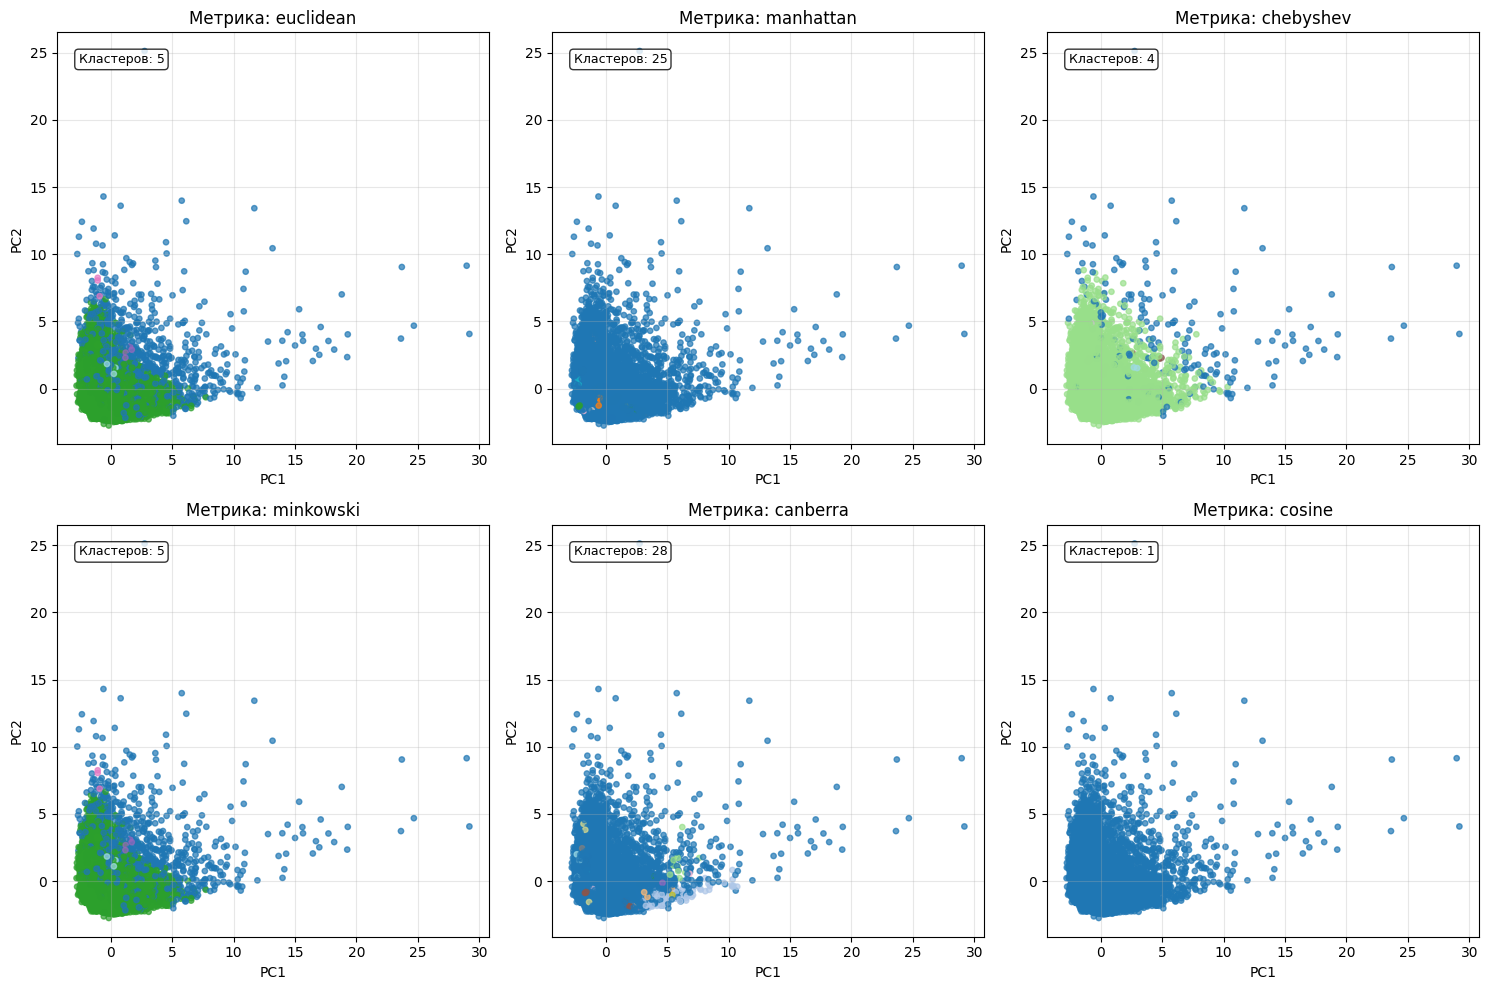

In [27]:
metrics = ['euclidean', 'manhattan', 'chebyshev', 'minkowski', 'canberra', 'cosine']
results = []

for metric in metrics:
    try:
        optics_metric = OPTICS(min_samples=best_min_samples, max_eps=best_eps,
                              metric=metric, cluster_method='dbscan')
        labels_metric = optics_metric.fit_predict(scaled_data)
        n_clusters = len(set(labels_metric)) - (1 if -1 in labels_metric else 0)
        n_noise = list(labels_metric).count(-1)
        noise_percent = n_noise / len(labels_metric) * 100
        results.append((metric, n_clusters, noise_percent))
        print(f"metric={metric}: кластеров={n_clusters}, шум={noise_percent:.2f}%")
    except Exception as e:
        print(f"metric={metric}: ошибка - {e}")

# Визуализация результатов для разных метрик
print("\n=== Визуализация для различных метрик ===")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, metric in enumerate(metrics[:6]):
    try:
        optics_metric = OPTICS(min_samples=best_min_samples, max_eps=best_eps,
                              metric=metric, cluster_method='dbscan')
        labels_metric = optics_metric.fit_predict(scaled_data)

        axes[idx].scatter(data_pca[:, 0], data_pca[:, 1], c=labels_metric,
                         cmap='tab20', s=15, alpha=0.7)
        axes[idx].set_title(f'Метрика: {metric}')
        axes[idx].set_xlabel('PC1')
        axes[idx].set_ylabel('PC2')
        axes[idx].grid(True, alpha=0.3)

        n_clusters = len(set(labels_metric)) - (1 if -1 in labels_metric else 0)
        axes[idx].text(0.05, 0.95, f'Кластеров: {n_clusters}',
                      transform=axes[idx].transAxes, fontsize=9,
                      verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    except:
        axes[idx].text(0.5, 0.5, f'{metric}\nошибка', ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(f'Метрика: {metric}')

plt.tight_layout()
plt.show()

Выводы по метрикам:
- Евклидова метрика: стандартный выбор, работает хорошо для нормализованных данных
- Манхэттенская метрика: устойчива к выбросам, но может давать разные результаты
- Чебышева метрика: учитывает максимальное отклонение, подходит для гиперкубов
- Минковского: обобщение евклидовой и манхэттенской
- Канберра: взвешенная метрика, устойчива к масштабу
- Косинусная: хорошо работает для разреженных данных, но требует положительных значений

## Выводы

В ходе работы были изучены методы кластеризации DBSCAN и OPTICS. DBSCAN показал зависимость результатов от параметров eps и min_samples. Определены оптимальные параметры, при которых количество кластеров составляет 5-7, а доля шума не превышает 12%. Визуализация в пространстве PCA позволила наглядно оценить результаты.

OPTICS, в отличие от DBSCAN, не требует жесткого задания eps и способен находить кластеры разной плотности. Построен график достижимости (reachability plot), позволяющий анализировать иерархическую структуру кластеров. Исследованы различные метрики расстояния, показано их влияние на результат кластеризации.